<a href="https://colab.research.google.com/github/will-the-wise/credit-risk-project/blob/main/TimeSeries_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [60]:
df = pd.read_csv('/content/RBIB Table No. 19 _ Consumer Price Index (Base 2010=100).csv')

# Set the first row as column names
df.columns = df.iloc[0]

# Drop the first two rows (original headers and an empty row)
df = df[2:].copy()

# Rename columns for convenience
df = df.rename(columns={'Month': 'Date', 'Combined': 'Value'})

# Convert 'Date' to datetime with a specified format to avoid warnings
df['Date'] = pd.to_datetime(df['Date'], format='%b-%Y')

# Set index
df.set_index('Date', inplace=True)

# Sort data
df = df.sort_index()

# Convert 'Value' to numeric, coercing errors to NaN
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

# Select the 'Value' column
ts = df['Value']

# Trend component

In [61]:
df = df.copy()
df['t'] = np.arange(1, len(df) + 1)
df = df.dropna(subset=['Value'])

In [62]:
import statsmodels.api as sm

X = sm.add_constant(df['t'])   # adds intercept
y = df['Value']                # your CPI column

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     8040.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          1.65e-133
Time:                        04:56:07   Log-Likelihood:                -419.06
No. Observations:                 154   AIC:                             842.1
Df Residuals:                     152   BIC:                             848.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        102.8063      0.599    171.490      0.0

In [63]:
df['trend'] = model.predict(X)

In [64]:
df['detrended'] = df['Value'] - df['trend']


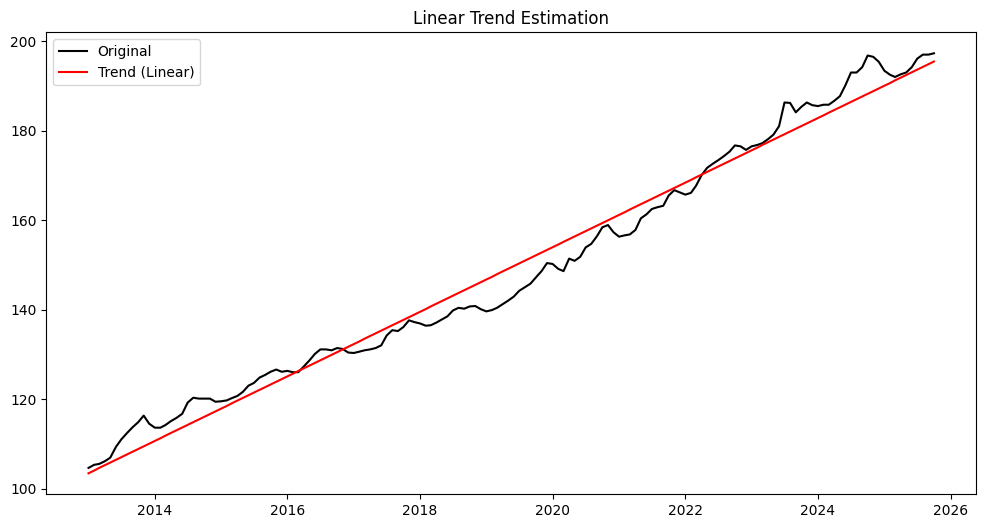

In [65]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Value'], label="Original", color='black')
plt.plot(df.index, df['trend'], label="Trend (Linear)", color='red')

plt.legend()
plt.title("Linear Trend Estimation")
plt.show()

In [66]:
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
df = df.dropna(subset=['Value'])
df['trend'] = model.predict(X)

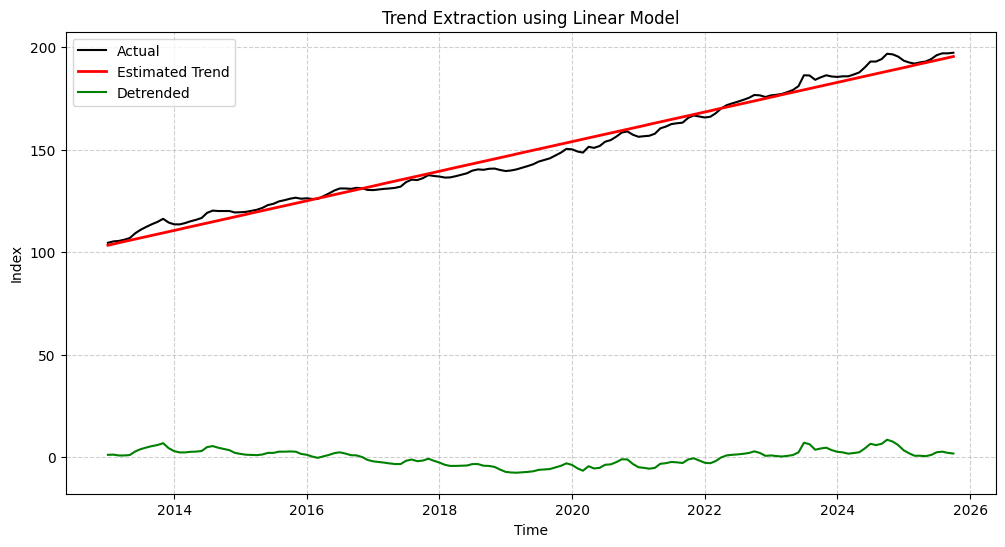

In [67]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Value'], label="Actual", color='black')
plt.plot(df.index, df['trend'], label="Estimated Trend", color='red', linewidth=2)
plt.plot(df.index, df['detrended'], label="Detrended", color='green')

plt.legend()
plt.title("Trend Extraction using Linear Model")
plt.xlabel("Time")
plt.ylabel("Index")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [68]:
print(model.params)

const    102.806315
t          0.601628
dtype: float64


In [69]:
df['detrended'] = df['Value'] - df['trend']

In [70]:
df

,Commodity Description,Provisional / Final,Value,NaN,NaN,t,trend,detrended
Date,,,,,,,,
2013-01-01,A) General Index,Final,104.6,NaN,NaN,1,103.407943,1.192057
2013-02-01,A) General Index,Final,105.3,NaN,NaN,2,104.009571,1.290429
2013-03-01,A) General Index,Final,105.5,NaN,NaN,3,104.611199,0.888801
2013-04-01,A) General Index,Final,106.1,NaN,NaN,4,105.212826,0.887174
2013-05-01,A) General Index,Final,106.9,NaN,NaN,5,105.814454,1.085546
...,...,...,...,...,...,...,...,...
2025-06-01,A) General Index,Final,194.2,2.1,NaN,150,193.050481,1.149519
2025-07-01,A) General Index,Final,196.1,1.61,NaN,151,193.652109,2.447891
2025-08-01,A) General Index,Final,197.0,2.07,NaN,152,194.253736,2.746264


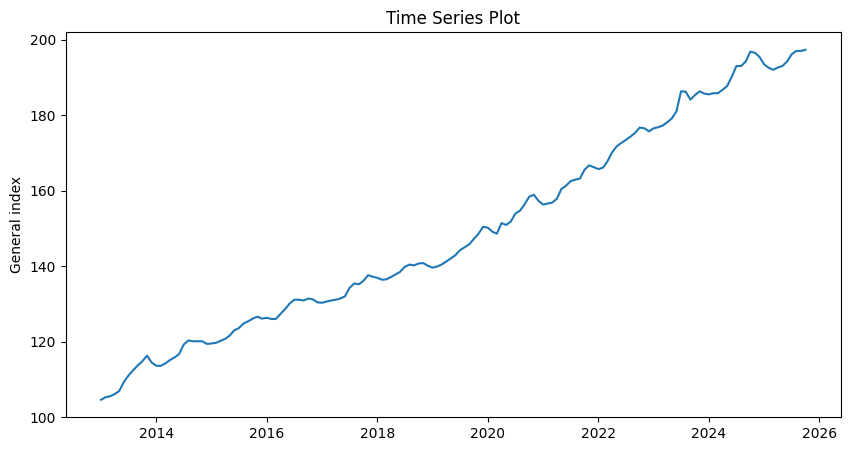

In [71]:
plt.figure(figsize=(10,5))
plt.plot(ts)   # label for x-axis
plt.ylabel("General index")
plt.title("Time Series Plot")
plt.show()

In [72]:
model_type = "additive"   # or "multiplicative"

In [73]:
decomp = seasonal_decompose(ts.dropna(), model=model_type, period=12)

trend = decomp.trend
seasonal = decomp.seasonal
residual = decomp.resid

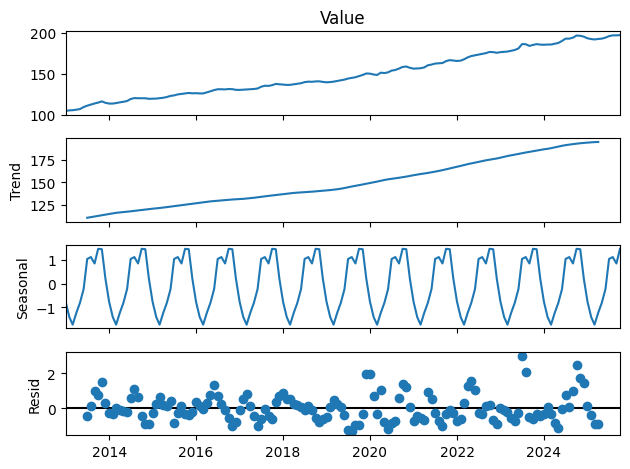

In [74]:
decomp.plot()
plt.show()

In [75]:
# # Detrend
# detrended = ts - trend if model_type == "additive" else ts / trend

# # Create month column
# df['month'] = df.index.month
# df['detrended'] = detrended

# # Seasonal indices
# seasonal_index = df.groupby('month')['detrended'].mean()

# # NORMALIZATION (VERY IMPORTANT)
# if model_type == "multiplicative":
#     seasonal_index = seasonal_index / seasonal_index.mean()
# else:
#     seasonal_index = seasonal_index - seasonal_index.mean()

# print(seasonal_index)

In [76]:
# df['seasonal'] = df['month'].map(seasonal_index)

# if model_type == "additive":
#     df['deseasonalized'] = ts - df['seasonal']
# else:
#     df['deseasonalized'] = ts / df['seasonal']

In [77]:
#print(hw_fit.summary())

SHOWING SEASONALITY

# Seasonality graphs


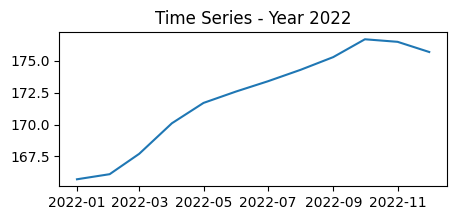

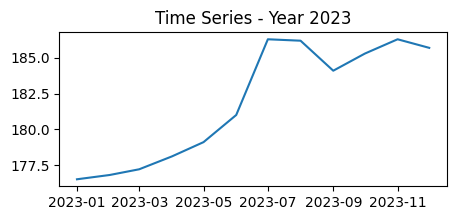

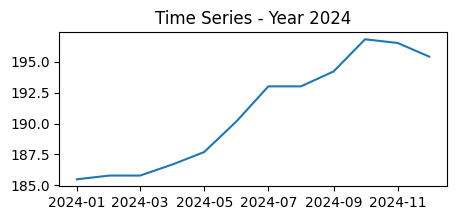

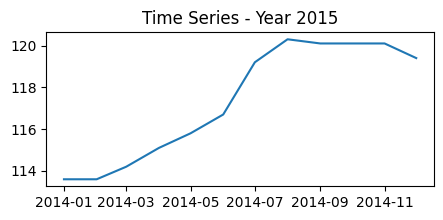

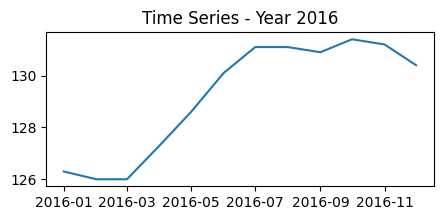

In [78]:
plt.figure(figsize=(5,2))
year_data = ts['2022']
plt.plot(year_data)
plt.title("Time Series - Year 2022")
plt.show()

plt.figure(figsize=(5,2))
year_data = ts['2023']
plt.plot(year_data)
plt.title("Time Series - Year 2023")
plt.show()

plt.figure(figsize=(5,2))
year_data = ts['2024']
plt.plot(year_data)
plt.title("Time Series - Year 2024")
plt.show()

plt.figure(figsize=(5,2))
year_data = ts['2014']
plt.plot(year_data)
plt.title("Time Series - Year 2015")
plt.show()

plt.figure(figsize=(5,2))
year_data = ts['2016']
plt.plot(year_data)
plt.title("Time Series - Year 2016")
plt.show()

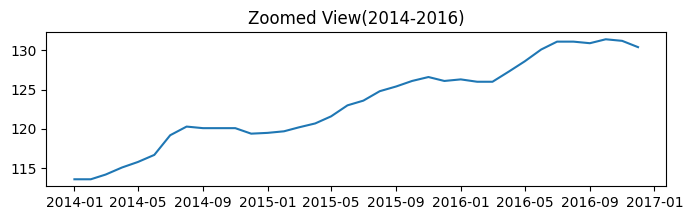

In [79]:
plt.figure(figsize=(8,2))
ts_filtered = ts[ts.index.notna()].sort_index()
subset = ts_filtered['2014-01-01':'2016-12-31']
plt.plot(subset)
plt.title("Zoomed View(2014-2016)")
plt.show()

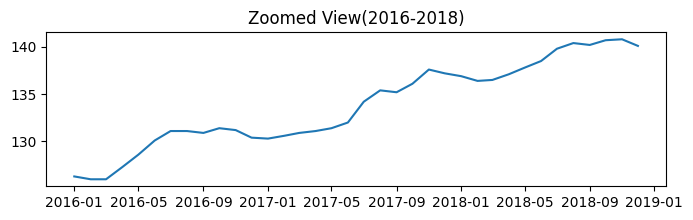

In [80]:
plt.figure(figsize=(8,2))
ts_filtered = ts[ts.index.notna()].sort_index()
subset = ts_filtered['2016-01-01':'2018-12-31']
plt.plot(subset)
plt.title("Zoomed View(2016-2018)")
plt.show()

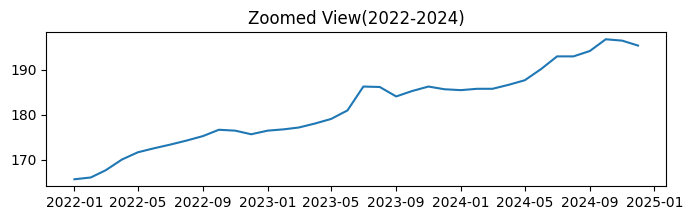

In [81]:
plt.figure(figsize=(8,2))
ts_filtered = ts[ts.index.notna()].sort_index()
subset = ts_filtered['2022-01-01':'2024-12-31']
plt.plot(subset)
plt.title("Zoomed View(2022-2024)")
plt.show()

#Models

In [82]:
# def calculate_rss(y_true, y_pred):
#     return np.sum((y_true - y_pred) ** 2)

In [83]:
# rss_ses = calculate_rss(test, ses_forecast)
# rss_holt = calculate_rss(test, holt_forecast)
# rss_hw = calculate_rss(test, hw_forecast)

# print("RSS Values:")
# print(f"SES: {rss_ses:.2f}")
# print(f"Holt: {rss_holt:.2f}")
# print(f"Holt-Winters: {rss_hw:.2f}")

In [84]:
# SES
ses_model = ExponentialSmoothing(ts, trend=None, seasonal=None)
ses_fit = ses_model.fit()

ses_fitted = ses_fit.fittedvalues

# Holt
holt_model = ExponentialSmoothing(ts, trend='add', seasonal=None)
holt_fit = holt_model.fit()

holt_fitted = holt_fit.fittedvalues
# Holt-Winters
hw_model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

hw_fit = hw_model.fit()

hw_fitted = hw_fit.fittedvalues

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date in

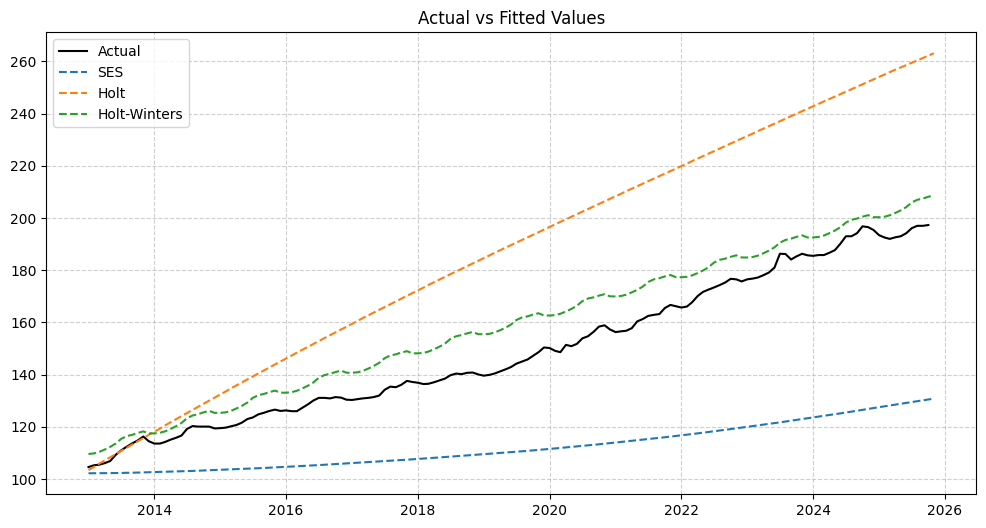

In [85]:
plt.figure(figsize=(12,6))

plt.plot(ts, label="Actual", color='black')

plt.plot(ses_fitted, label="SES", linestyle='--')
plt.plot(holt_fitted, label="Holt", linestyle='--')
plt.plot(hw_fitted, label="Holt-Winters", linestyle='--')

plt.legend()
plt.title("Actual vs Fitted Values")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [86]:
def rss(y, yhat):
    return np.sum((y - yhat)**2)

rss_ses = rss(ts, ses_fitted)
rss_holt = rss(ts, holt_fitted)
rss_hw = rss(ts, hw_fitted)

print("SES:", rss_ses)
print("Holt:", rss_holt)
print("Holt-Winters:", rss_hw)

SES: 266950.1717010834
Holt: 276666.7676409171
Holt-Winters: 15992.326622662107


In [87]:
print(ses_fit.params)
print(holt_fit.params)
print(hw_fit.params)

{'smoothing_level': np.float64(0.005), 'smoothing_trend': np.float64(nan), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(102.21999999999994), 'initial_trend': np.float64(nan), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
{'smoothing_level': np.float64(0.005), 'smoothing_trend': np.float64(0.0001), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(102.21999999999994), 'initial_trend': np.float64(1.2254545454545536), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
{'smoothing_level': np.float64(0.005), 'smoothing_trend': np.float64(0.0001), 'smoothing_seasonal': np.float64(0.0001), 'damping_trend': nan, 'initial_level': np.float64(109.82972222222216), 'initial_trend': np.float64(0.6775505050505135), 'initial_seasons': array([-0.89444444, -1.32569444, -1.43923611, -1.16006944, -0.80381944,
       

In [88]:
# plt.figure(figsize=(8,5))
# df['inflation'].hist(bins=20)
# plt.title("Distribution of Inflation")
# plt.xlabel("Inflation (%)")
# plt.show()

# Seasonal component


In [89]:
df['month'] = df.index.month

In [90]:
seasonal_index = df.groupby('month')['detrended'].mean()

In [91]:
seasonal_index = seasonal_index - seasonal_index.mean()

In [92]:
print(seasonal_index.mean())

3.5850951836854015e-17


In [93]:
df['seasonal'] = df['month'].map(seasonal_index)

In [94]:
print(seasonal_index)

month
1    -0.704053
2    -1.305681
3    -1.645770
4    -1.208937
5    -0.918257
6    -0.235269
7     1.063103
8     1.169168
9     0.875232
10    1.419758
11    1.367000
12    0.123705
Name: detrended, dtype: float64


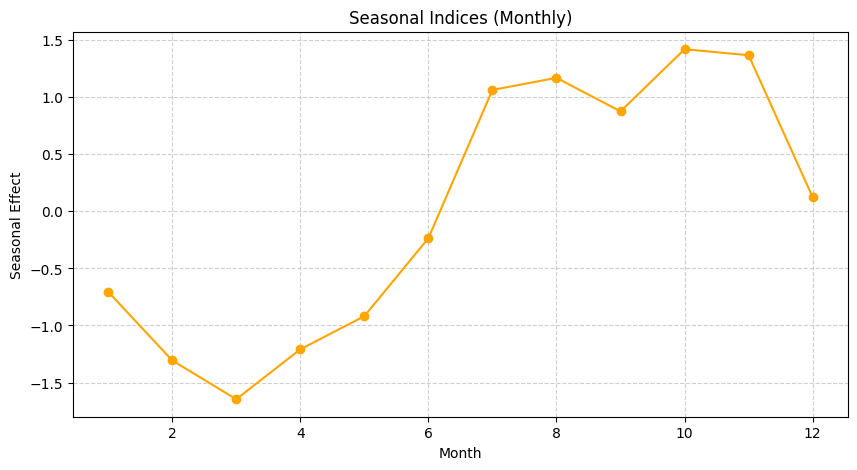

In [95]:
plt.figure(figsize=(10,5))

seasonal_index.plot(marker='o', color='orange')

plt.title("Seasonal Indices (Monthly)")
plt.xlabel("Month")
plt.ylabel("Seasonal Effect")

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Irregular

In [96]:
df['irregular'] = df['Value'] - df['trend'] - df['seasonal']

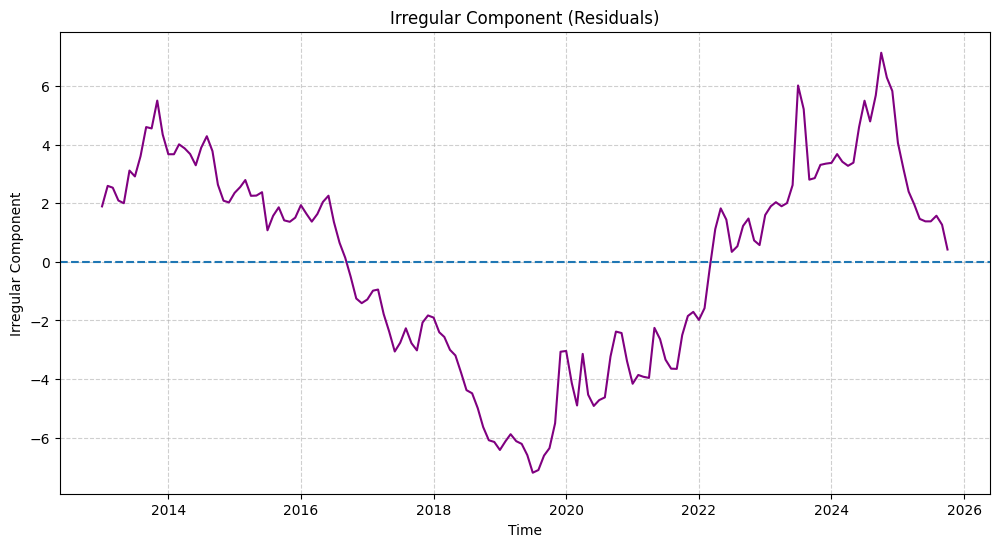

In [97]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['irregular'], color='purple')

plt.axhline(0, linestyle='--')  # zero reference line

plt.title("Irregular Component (Residuals)")
plt.xlabel("Time")
plt.ylabel("Irregular Component")

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

FIXING THIS

---



In [98]:
#ADDING QUADRATIC TREND
df['t2'] = df['t']**2

X = sm.add_constant(df[['t', 't2']])
y = df['Value']

model2 = sm.OLS(y, X).fit()

df['trend2'] = model2.predict(X)

In [99]:
df['detrended2'] = df['Value'] - df['trend2']

In [100]:
seasonal_index2 = df.groupby('month')['detrended2'].mean()


In [101]:
seasonal_index2 = seasonal_index2 - seasonal_index2.mean()

In [102]:
print(seasonal_index2.mean())

6.47630097698008e-17


In [103]:
df['seasonal2'] = df['month'].map(seasonal_index2)

In [104]:
print(seasonal_index2)

month
1    -0.804667
2    -1.393586
3    -1.724144
4    -1.280955
5    -0.987098
6    -0.304110
7     0.991085
8     1.090795
9     0.787327
10    1.319144
11    1.774752
12    0.531458
Name: detrended2, dtype: float64


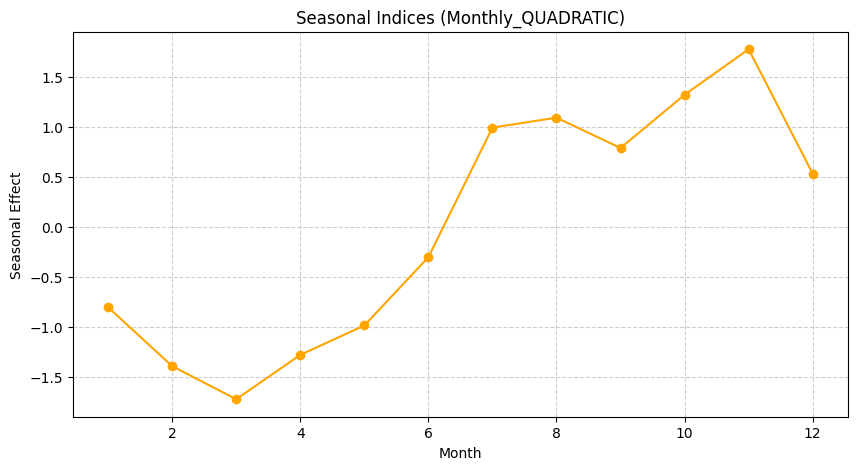

In [105]:
plt.figure(figsize=(10,5))

seasonal_index2.plot(marker='o', color='orange')

plt.title("Seasonal Indices (Monthly_QUADRATIC)")
plt.xlabel("Month")
plt.ylabel("Seasonal Effect")

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [106]:
df['irregular2'] = df['Value'] - df['trend2'] - df['seasonal2']

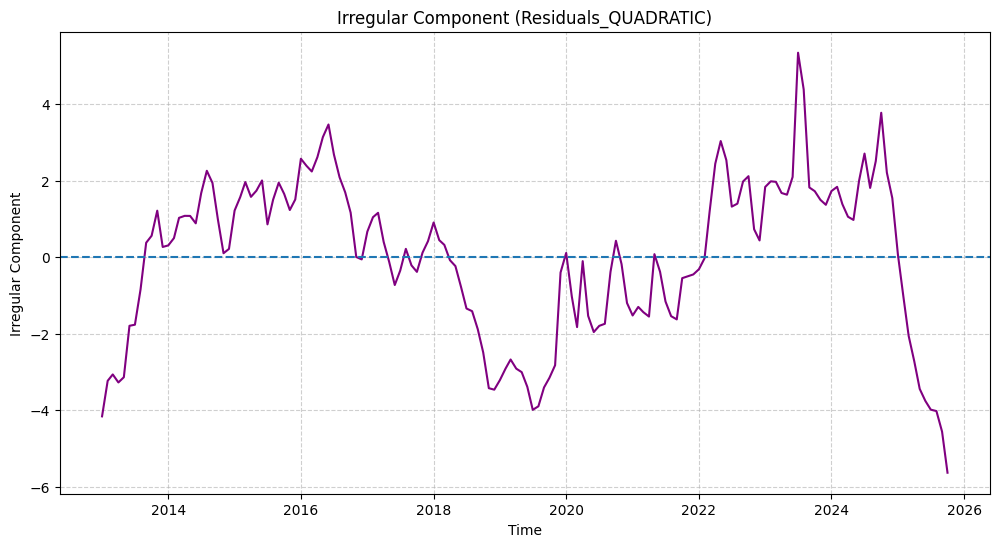

In [107]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['irregular2'], color='purple')

plt.axhline(0, linestyle='--')  # zero reference line

plt.title("Irregular Component (Residuals_QUADRATIC)")
plt.xlabel("Time")
plt.ylabel("Irregular Component")

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Forecasting

In [108]:
h = 24   # 24 months = 2 years

In [109]:
ses_forecast = ses_fit.forecast(h)
holt_forecast = holt_fit.forecast(h)
hw_forecast = hw_fit.forecast(h)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/u

In [110]:
future_dates = pd.date_range(
    start=ts.dropna().index[-1], # Ensure the last date is not NaT
    periods=h+1,
    freq='M'
)[1:]

/tmp/ipykernel_944/1128939908.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


In [111]:
seasonal='add'
seasonal_periods=12

In [112]:
ses_forecast.index = future_dates
holt_forecast.index = future_dates
hw_forecast.index = future_dates

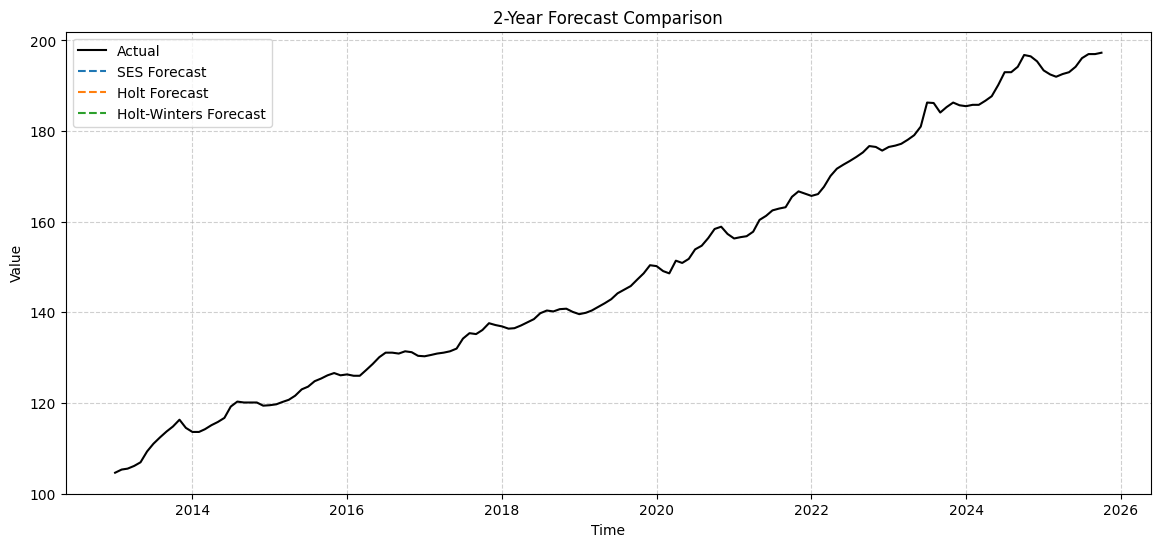

In [113]:
plt.figure(figsize=(14,6))

# Actual data
plt.plot(ts, label="Actual", color='black')

# Forecasts
plt.plot(ses_forecast, label="SES Forecast", linestyle='--')
plt.plot(holt_forecast, label="Holt Forecast", linestyle='--')
plt.plot(hw_forecast, label="Holt-Winters Forecast", linestyle='--')

plt.title("2-Year Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [114]:
print(ses_forecast.head())
print(holt_forecast.head())
print(hw_forecast.head())

2025-11-30   NaN
2025-12-31   NaN
2026-01-31   NaN
2026-02-28   NaN
2026-03-31   NaN
Freq: ME, dtype: float64
2025-11-30   NaN
2025-12-31   NaN
2026-01-31   NaN
2026-02-28   NaN
2026-03-31   NaN
Freq: ME, dtype: float64
2025-11-30   NaN
2025-12-31   NaN
2026-01-31   NaN
2026-02-28   NaN
2026-03-31   NaN
Freq: ME, dtype: float64
